# Import Libraries

In [20]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings                                                                      
warnings.filterwarnings('ignore')  
from IPython.display import Audio, display, Markdown
import librosa
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import Audio, display

# Loading Data

In [21]:
tess_path = '../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data'

In [22]:
tess_file_paths = []
tess_labels = []

for folder in os.listdir(tess_path):
    folder_path = os.path.join(tess_path, folder)
    label = folder[4:] 
    label = label.lower() 

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        tess_file_paths.append(file_path)
        tess_labels.append(label)

In [23]:
tess_data = pd.DataFrame({
    'paths' : tess_file_paths,
    'emotions' : tess_labels
})

# EDA

## Sampling rate check

In [5]:
def get_sampling_rate(path):
    try:
        y, sr = librosa.load(path, sr=None)   
        return sr
    except:
        return None

tess_data['sampling_rate'] = tess_data['paths'].apply(get_sampling_rate)

sampling_counts = tess_data['sampling_rate'].value_counts().reset_index()
sampling_counts.columns = ['Sampling Rate (Hz)', 'Number of Files']

display(sampling_counts)

,Sampling Rate (Hz),Number of Files
0,24414,2799
1,96000,1


## Audio duration check

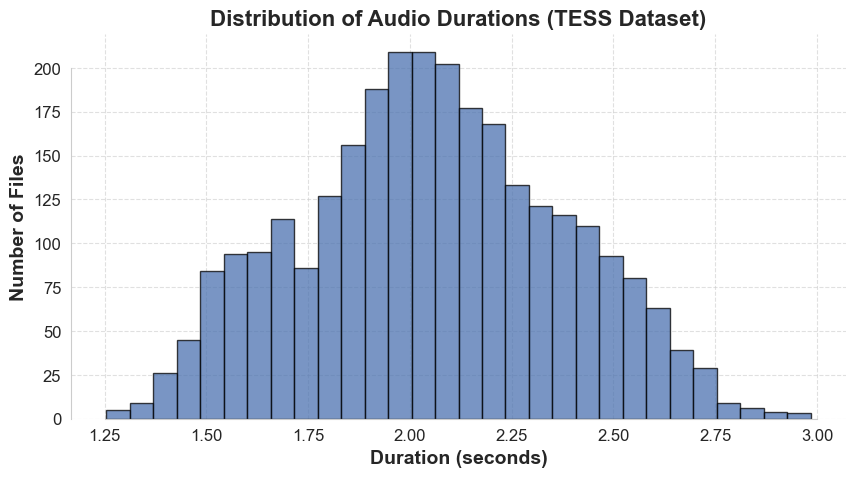

,paths,duration_sec
0,../Data/TESS Toronto emotional speech set data...,1.539035
1,../Data/TESS Toronto emotional speech set data...,1.616613
2,../Data/TESS Toronto emotional speech set data...,1.542025
3,../Data/TESS Toronto emotional speech set data...,1.606865
4,../Data/TESS Toronto emotional speech set data...,1.395183


In [6]:
durations = []

for path in tess_data['paths']:
    y, sr = librosa.load(path, sr=None)  
    duration = librosa.get_duration(y=y, sr=sr)
    durations.append(duration)

tess_data['duration_sec'] = durations

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

plt.hist(tess_data['duration_sec'], bins=30, color='#4C72B0', edgecolor='black', alpha=0.75)

plt.xlabel("Duration (seconds)", fontsize=14, weight='bold')
plt.ylabel("Number of Files", fontsize=14, weight='bold')
plt.title("Distribution of Audio Durations (TESS Dataset)", fontsize=16, weight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine(trim=True)
plt.show()

tess_data[['paths', 'duration_sec']].head()

## Waveform analysis

In [7]:
def get_waveform_stats(path):
    try:
        y, sr = librosa.load(path, sr=None)
        return {
            "min_amp": float(np.min(y)),
            "max_amp": float(np.max(y)),
            "mean_amp": float(np.mean(y)),
            "std_amp": float(np.std(y))
        }
    except:
        return {
            "min_amp": None,
            "max_amp": None,
            "mean_amp": None,
            "std_amp": None
        }

waveform_stats = tess_data['paths'].apply(get_waveform_stats)

waveform_df = pd.DataFrame(list(waveform_stats))

tess_data = pd.concat([tess_data, waveform_df], axis=1)

display(tess_data[['paths', 'min_amp', 'max_amp', 'mean_amp', 'std_amp']].head())

,paths,min_amp,max_amp,mean_amp,std_amp
0,../Data/TESS Toronto emotional speech set data...,-0.337341,0.326202,0.000165,0.056031
1,../Data/TESS Toronto emotional speech set data...,-0.176117,0.174042,0.000053,0.028573
2,../Data/TESS Toronto emotional speech set data...,-0.265015,0.240540,0.000100,0.041019
3,../Data/TESS Toronto emotional speech set data...,-0.343719,0.314209,0.000126,0.058056
4,../Data/TESS Toronto emotional speech set data...,-0.282318,0.206024,-0.000121,0.037087


## Spectrogram analysis

,Spectrogram Frequency Bins,Number of Files
0,1025,2800


,Spectrogram Time Frames,Number of Files
0,86,94
1,87,94
2,88,87
3,90,85
4,91,83
5,84,78
6,95,77
7,85,76
8,93,74
9,81,72


,mean_db,max_db,total_energy
count,2800.000,2800.0,2800.000
mean,-63.140,-0.0,131338.602
std,3.377,0.0,170015.503
min,-73.199,-0.0,5564.746
25%,-65.514,0.0,32335.797
50%,-63.399,0.0,65939.664
75%,-60.981,0.0,146897.035
max,-51.000,0.0,1286357.750



Emotion: angry


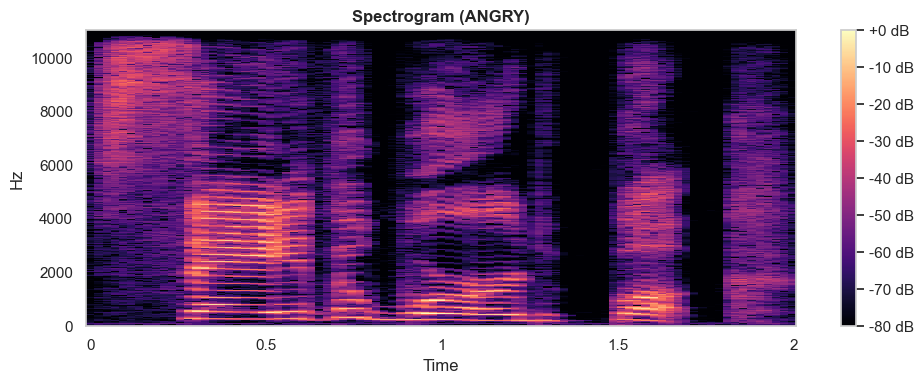


Emotion: disgust


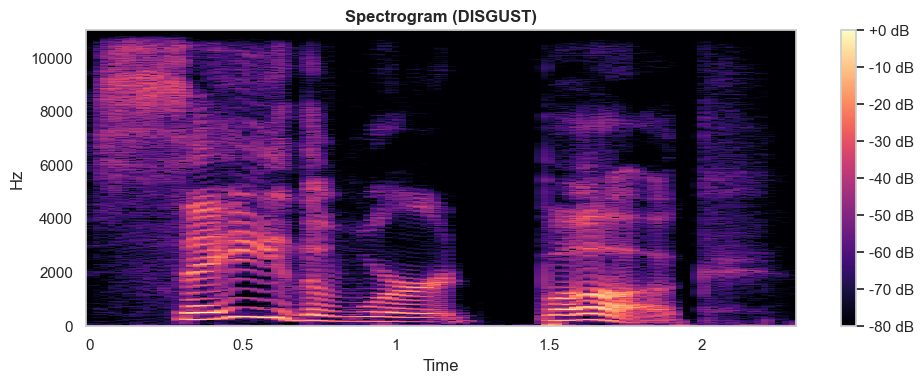


Emotion: fear


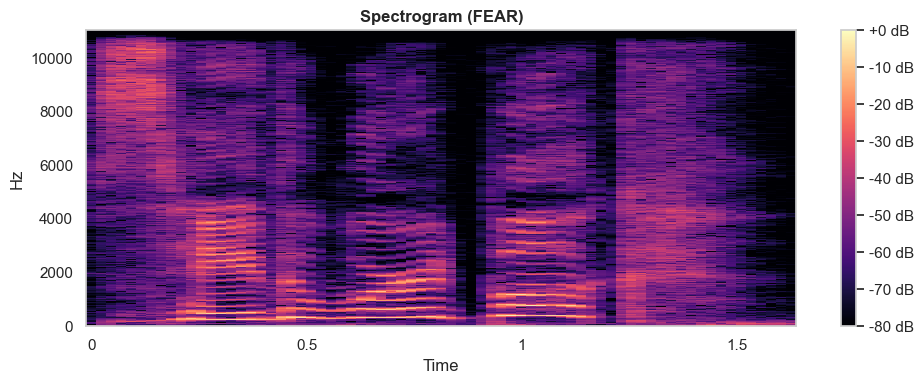


Emotion: happy


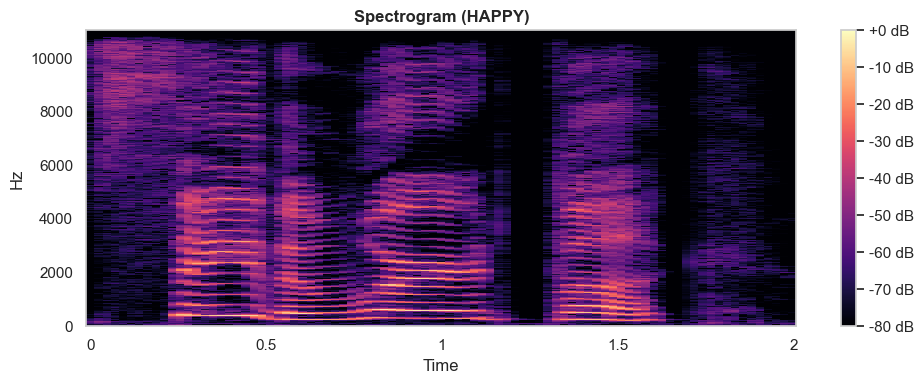


Emotion: neutral


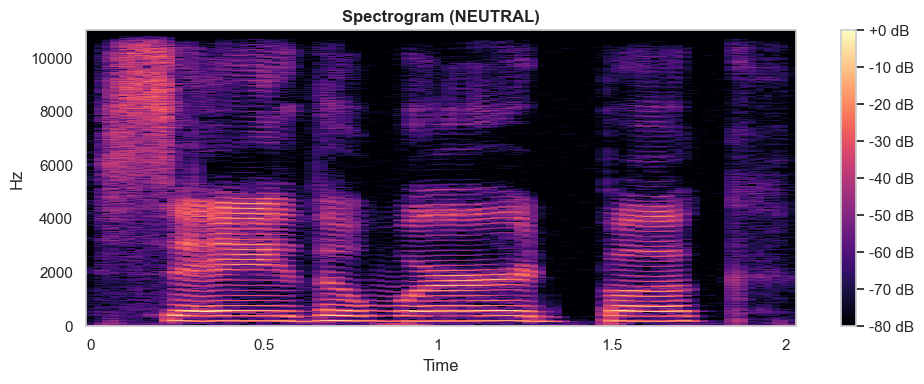


Emotion: pleasant_surprise


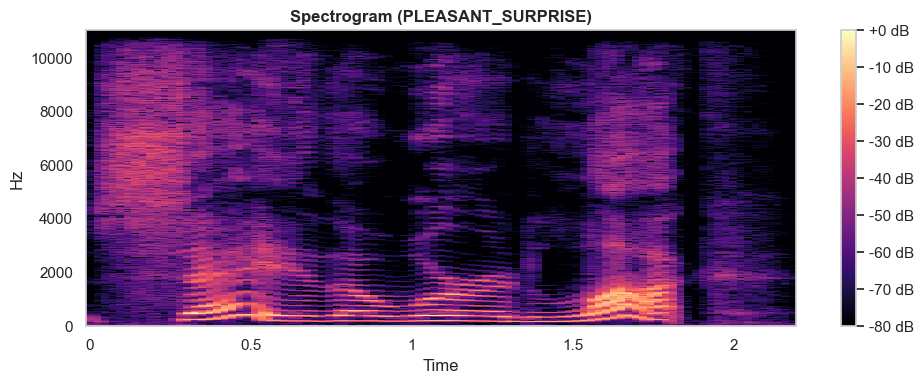


Emotion: sad


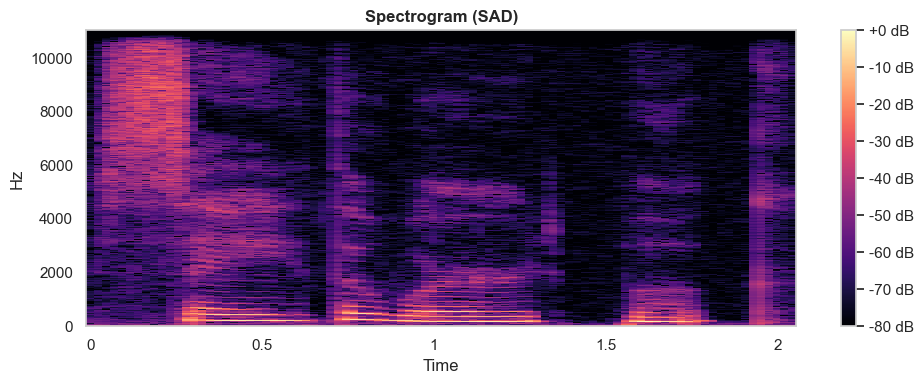


Emotion: pleasant_surprised


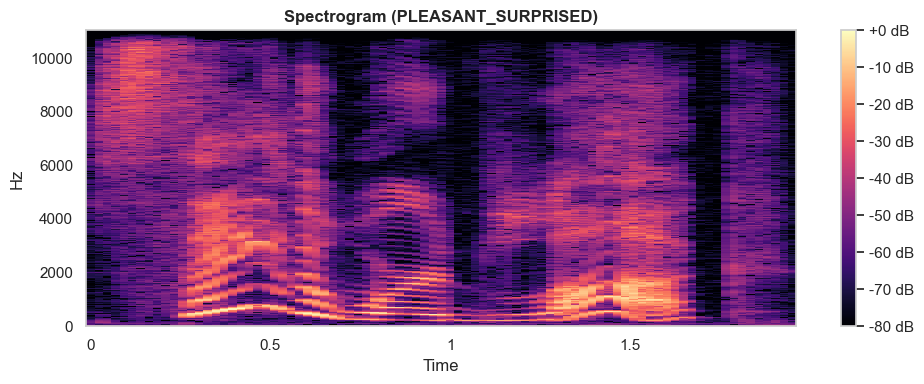

In [24]:
def get_spectrogram_stats(path, n_fft=2048, hop_length=512):
    try:
        y, sr = librosa.load(path, sr=22050)
        S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
        S_db = librosa.amplitude_to_db(S, ref=np.max)
        shape = S_db.shape               
        mean_db = float(np.mean(S_db))
        max_db = float(np.max(S_db))
        total_energy = float(np.sum(S**2))  
        return {
            "spec_freq_bins": int(shape[0]),
            "spec_time_frames": int(shape[1]),
            "mean_db": mean_db,
            "max_db": max_db,
            "total_energy": total_energy
        }
    except Exception as e:
        return {
            "spec_freq_bins": None,
            "spec_time_frames": None,
            "mean_db": None,
            "max_db": None,
            "total_energy": None
        }

spec_stats = tess_data['paths'].apply(lambda p: get_spectrogram_stats(p))
spec_df = pd.DataFrame(list(spec_stats))

tess_data = pd.concat([tess_data.reset_index(drop=True), spec_df.reset_index(drop=True)], axis=1)

freq_counts = tess_data['spec_freq_bins'].value_counts().reset_index()
freq_counts.columns = ['Spectrogram Frequency Bins', 'Number of Files']

timeframe_counts = tess_data['spec_time_frames'].value_counts().reset_index()
timeframe_counts.columns = ['Spectrogram Time Frames', 'Number of Files']

pd.set_option('display.max_rows', None)
display(freq_counts)
display(timeframe_counts)

display(tess_data[['mean_db', 'max_db', 'total_energy']].describe().round(3))

def plot_spectrogram(path, emotion, n_fft=2048, hop_length=512):
    y, sr = librosa.load(path, sr=22050)
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db, sr=sr, hop_length=hop_length,
        x_axis='time', y_axis='hz', cmap='magma'
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram ({emotion.upper()})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

for emo in tess_data['emotions'].unique():
    sample = tess_data[tess_data['emotions'] == emo]['paths'].sample(1, random_state=42).iloc[0]
    print(f"\nEmotion: {emo}")
    plot_spectrogram(sample, emo)

## MFCC 

In [9]:
def get_mfcc_size(path, n_mfcc=40):
    try:
        y, sr = librosa.load(path, sr=22050)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc.shape[0]   
    except:
        return None

tess_data['mfcc_size'] = tess_data['paths'].apply(get_mfcc_size)

mfcc_counts = tess_data['mfcc_size'].value_counts().reset_index()
mfcc_counts.columns = ['MFCC Feature Count', 'Number of Files']

display(mfcc_counts)

,MFCC Feature Count,Number of Files
0,40,2800


## Chroma STFT

In [10]:
def get_chroma_size(path):
    try:
        y, sr = librosa.load(path, sr=22050)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        return chroma.shape[0]   
    except:
        return None

tess_data['chroma_size'] = tess_data['paths'].apply(get_chroma_size)

chroma_counts = tess_data['chroma_size'].value_counts().reset_index()
chroma_counts.columns = ['Chroma Feature Count', 'Number of Files']

display(chroma_counts)

,Chroma Feature Count,Number of Files
0,12,2800


## Mel Spectrogram

In [11]:
def get_mel_size(path, n_mels=128):
    try:
        y, sr = librosa.load(path, sr=22050)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        return mel.shape[0]   
    except:
        return None

tess_data['mel_size'] = tess_data['paths'].apply(get_mel_size)

mel_counts = tess_data['mel_size'].value_counts().reset_index()
mel_counts.columns = ['Mel Feature Count', 'Number of Files']

display(mel_counts)

,Mel Feature Count,Number of Files
0,128,2800


## Pitch

Pitch Summary Statistics:


,Value
count,2800.00
mean,246.24
std,33.92
min,166.42
25%,217.68
50%,243.22
75%,272.78
max,353.01


Pitch Bucket Table:


,Pitch Range (Hz),Number of Files
0,0–100,0
1,100–200,189
2,200–300,2430
3,300–400,181
4,400–500,0


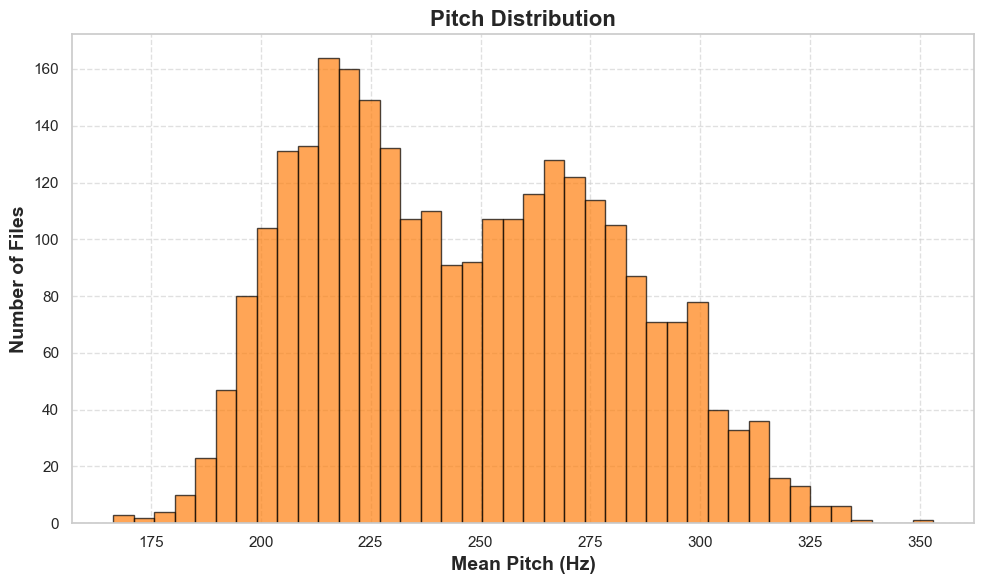

In [12]:
def get_mean_pitch(path, sr=22050, fmin=50, fmax=500):
    try:
        y, sr = librosa.load(path, sr=sr)
        f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr)
        f0 = f0[~np.isnan(f0)]       
        if len(f0) == 0:
            return np.nan           
        return float(np.mean(f0))
    except:
        return np.nan

tess_data['mean_pitch'] = tess_data['paths'].apply(get_mean_pitch)

pitch_summary = tess_data['mean_pitch'].describe().round(2)
pitch_summary_df = pd.DataFrame(pitch_summary)
pitch_summary_df.columns = ['Value']

print("Pitch Summary Statistics:")
display(pitch_summary_df)

pitch_buckets = pd.cut(
    tess_data['mean_pitch'].fillna(0),
    bins=[0,100,200,300,400,500],
    labels=['0–100', '100–200', '200–300', '300–400', '400–500']
).value_counts().sort_index()

pitch_bucket_df = pitch_buckets.reset_index()
pitch_bucket_df.columns = ['Pitch Range (Hz)', 'Number of Files']

print("Pitch Bucket Table:")
display(pitch_bucket_df)

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

plt.hist(tess_data['mean_pitch'].dropna(), bins=40, color='#FF7F0E', edgecolor='black', alpha=0.7)

# Customize labels and title for better readability
plt.xlabel('Mean Pitch (Hz)', fontsize=14, weight='bold')
plt.ylabel('Number of Files', fontsize=14, weight='bold')
plt.title('Pitch Distribution', fontsize=16, weight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

## Class imbalance check

,Emotion,Number of Files,Percent
0,angry,400,14.29
1,disgust,400,14.29
2,fear,400,14.29
3,happy,400,14.29
4,neutral,400,14.29
5,sad,400,14.29
6,pleasant_surprise,200,7.14
7,pleasant_surprised,200,7.14


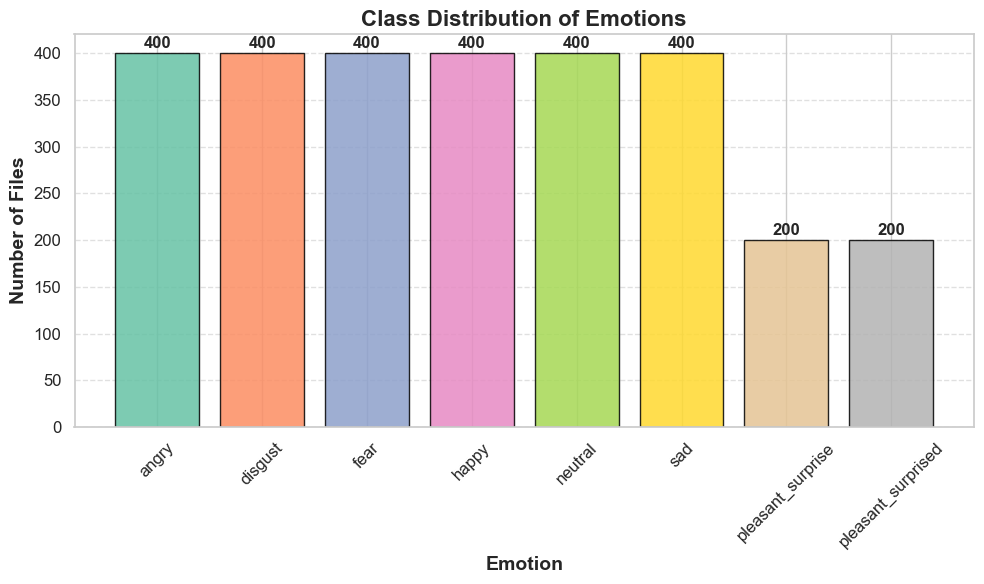

In [13]:
class_counts = tess_data['emotions'].value_counts().reset_index()
class_counts.columns = ['Emotion', 'Number of Files']

class_counts['Percent'] = (class_counts['Number of Files'] / class_counts['Number of Files'].sum() * 100).round(2)
display(class_counts)

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

colors = sns.color_palette("Set2", len(class_counts))

bars = plt.bar(class_counts['Emotion'], class_counts['Number of Files'],
               color=colors, edgecolor='black', alpha=0.85)

plt.xlabel('Emotion', fontsize=14, weight='bold')
plt.ylabel('Number of Files', fontsize=14, weight='bold')
plt.title('Class Distribution of Emotions', fontsize=16, weight='bold')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{int(height)}', 
             ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Analysing Emotion Counts and Percentages

,Emotion,Count,Percent (%)
0,angry,400,14.29
1,disgust,400,14.29
2,fear,400,14.29
3,happy,400,14.29
4,neutral,400,14.29
5,sad,400,14.29
6,pleasant_surprise,200,7.14
7,pleasant_surprised,200,7.14


Unique Labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'pleasant_surprise' 'sad'
 'pleasant_surprised']


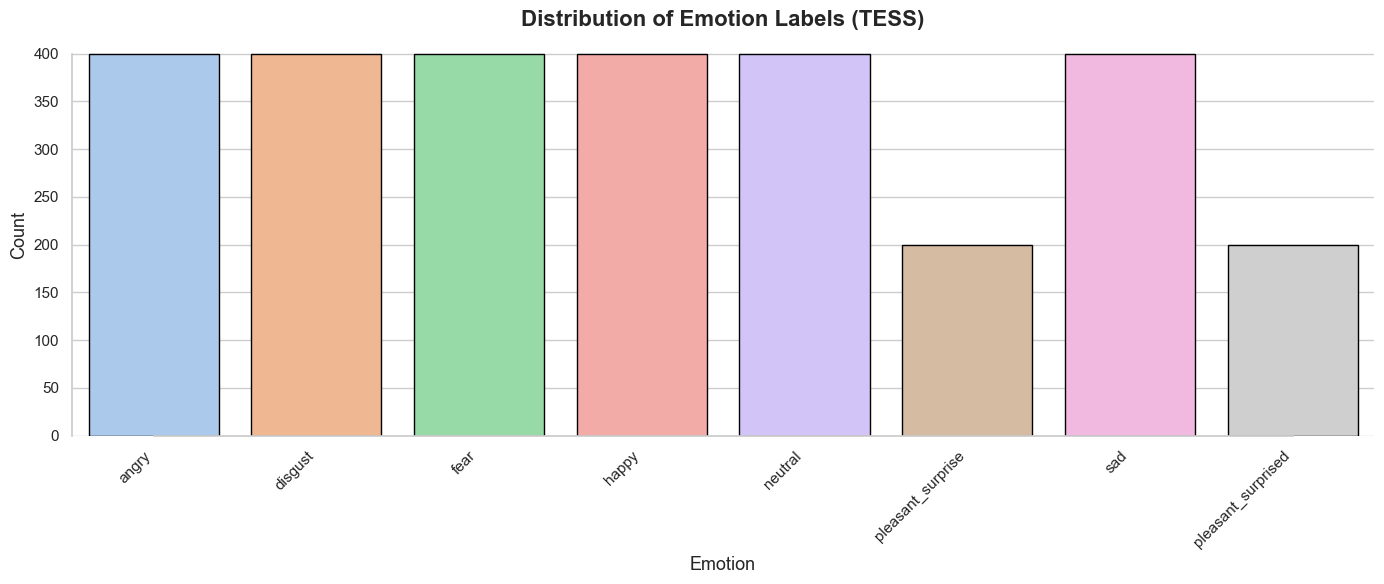

In [14]:
emotion_summary = (
    tess_data['emotions']
    .value_counts()
    .reset_index()
)

emotion_summary.columns = ['Emotion', 'Count']
emotion_summary['Percent (%)'] = (
    emotion_summary['Count'] / emotion_summary['Count'].sum() * 100
).round(2)

display(emotion_summary)

print("Unique Labels:", tess_data['emotions'].unique())

sns.set(style="whitegrid")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})

plt.figure(figsize=(14, 6))
palette = sns.color_palette("pastel", emotion_summary.shape[0])

sns.countplot(
    x='emotions',
    data=tess_data,
    palette=palette,
    edgecolor='black'
)

plt.title("Distribution of Emotion Labels (TESS)", fontsize=16, fontweight='bold')
plt.xlabel("Emotion", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)

sns.despine(trim=True)
plt.tight_layout()
plt.show()

# Visualizing Class Distributions in the TESS Dataset

,Emotion,Files,Mean Duration (s),Mean Pitch (Hz),Min Duration,Max Duration
0,angry,400,1.84,253.90,1.29,2.50
1,disgust,400,2.45,211.45,2.02,2.86
2,fear,400,1.66,290.30,1.25,2.06
3,happy,400,1.97,266.52,1.63,2.31
4,neutral,400,2.05,216.01,1.72,2.37
5,pleasant_surprise,200,2.04,249.97,1.68,2.46
6,pleasant_surprised,200,1.97,282.97,1.65,2.45
7,sad,400,2.40,219.06,1.94,2.98


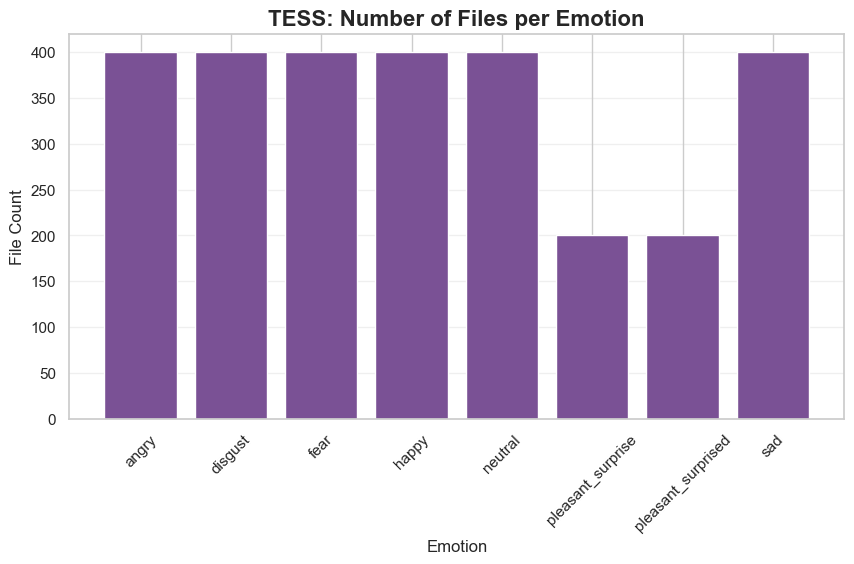

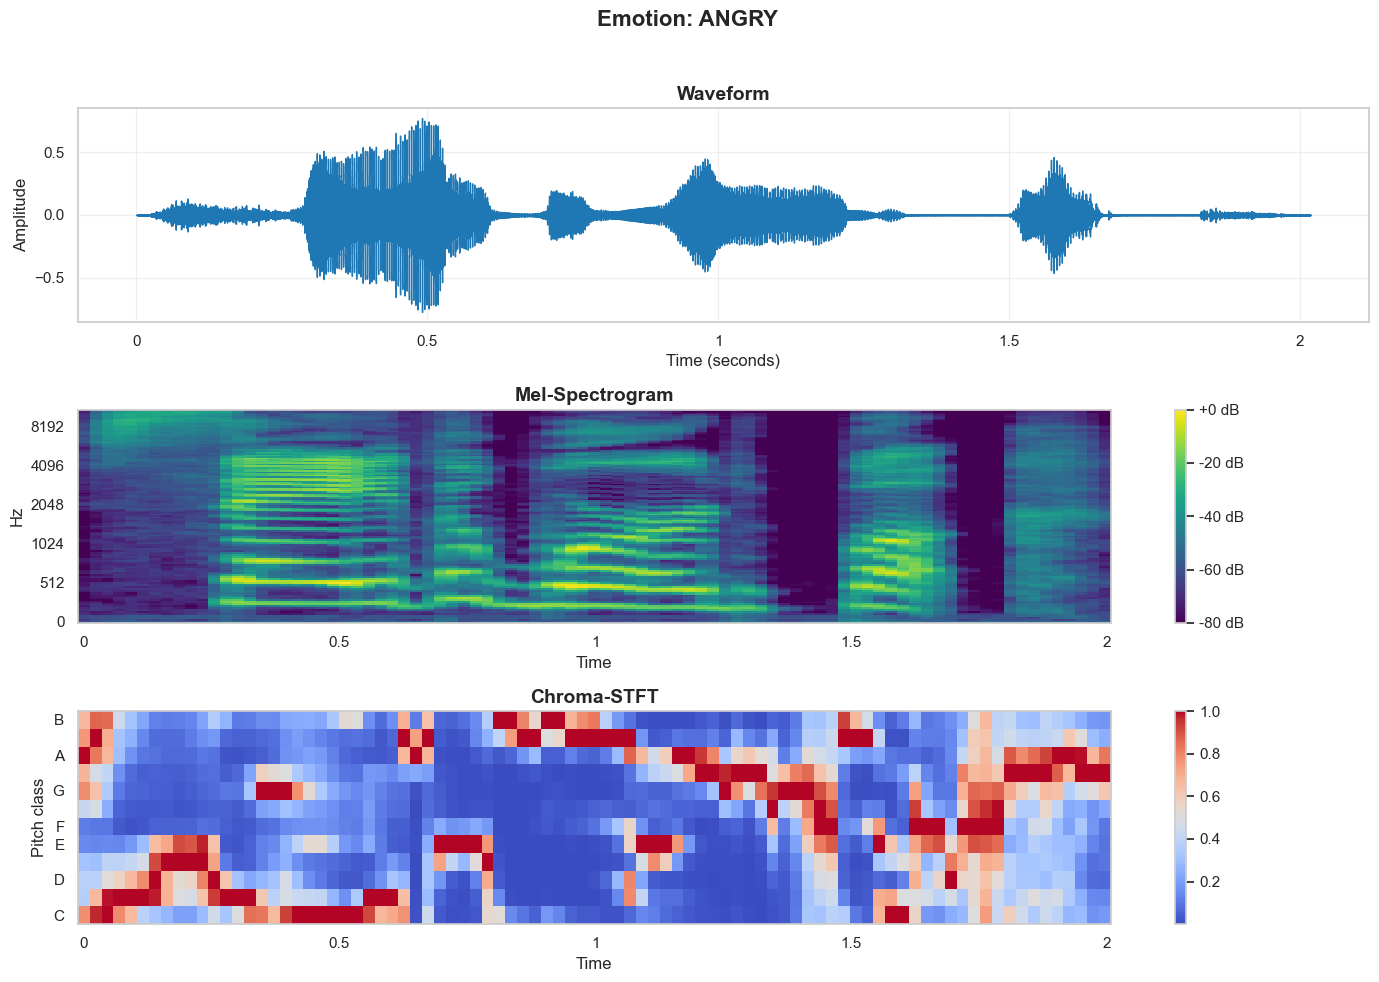

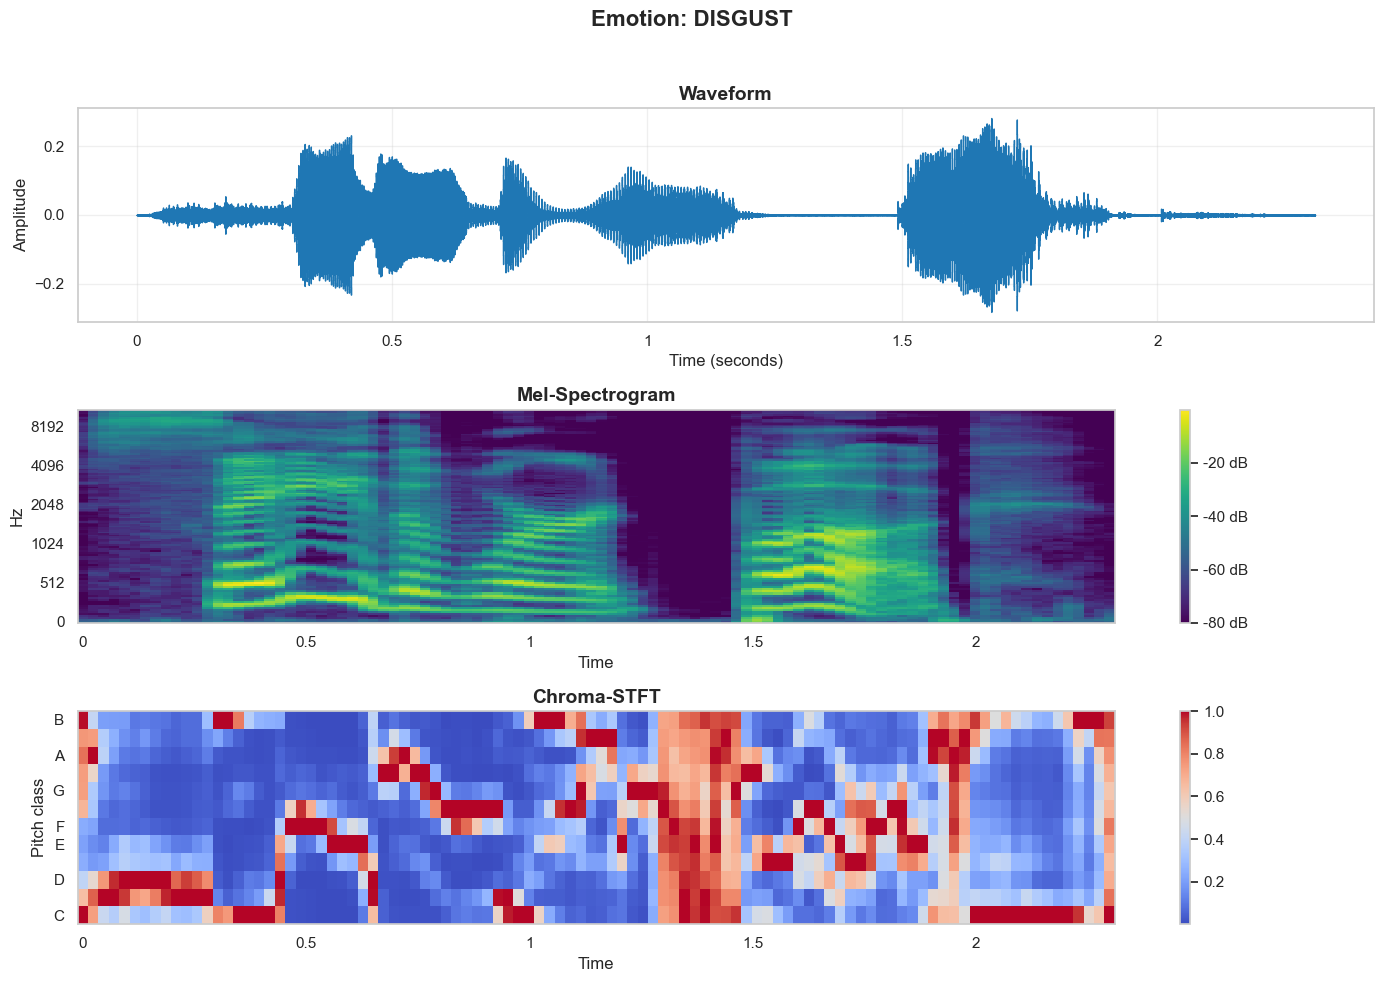

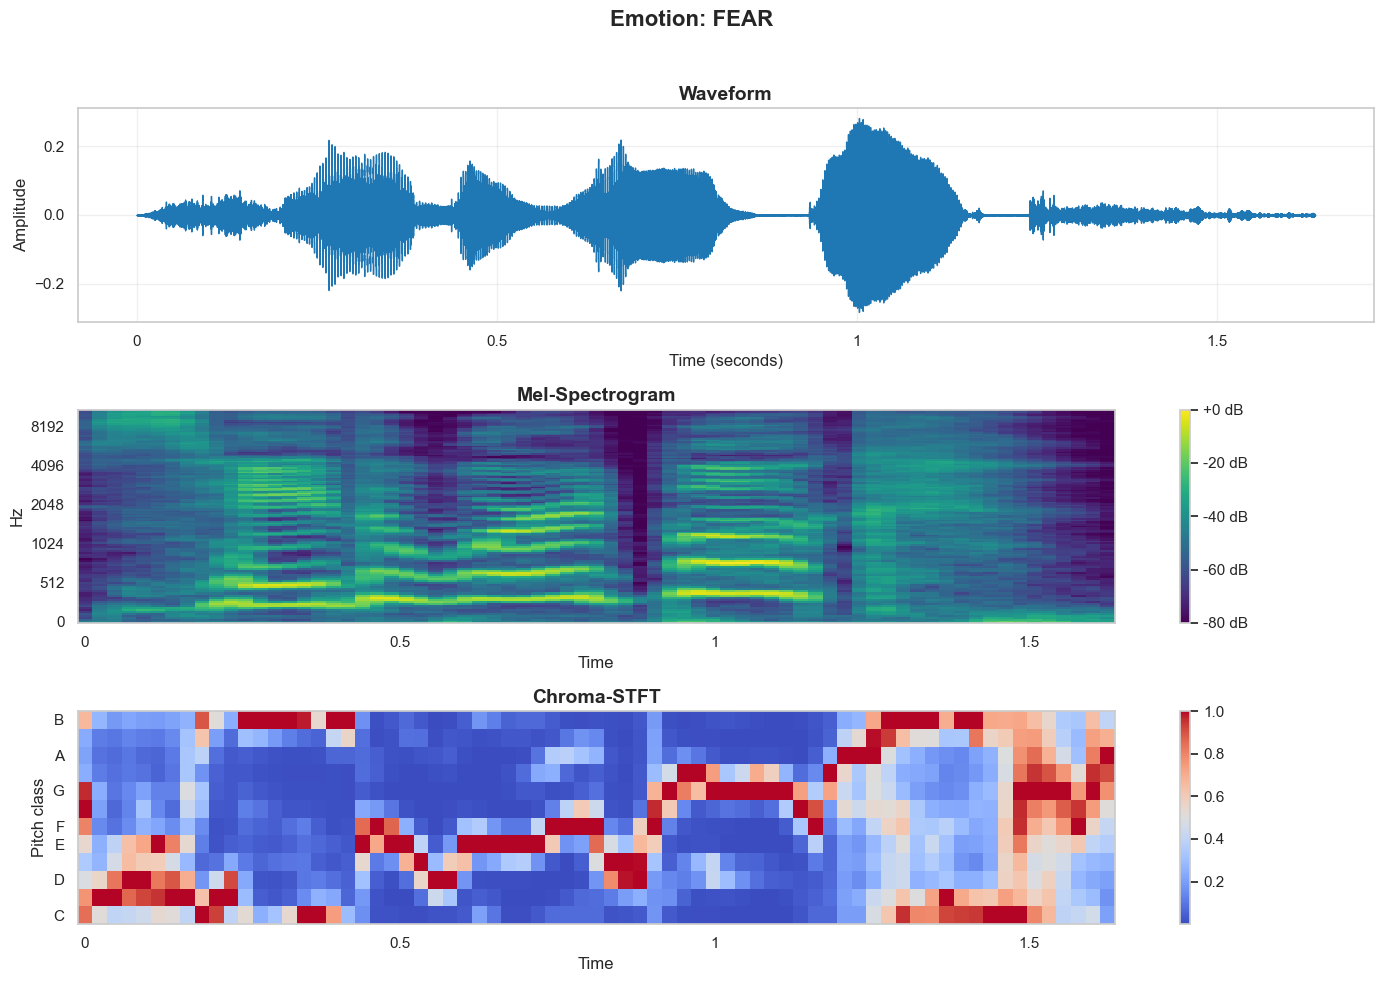

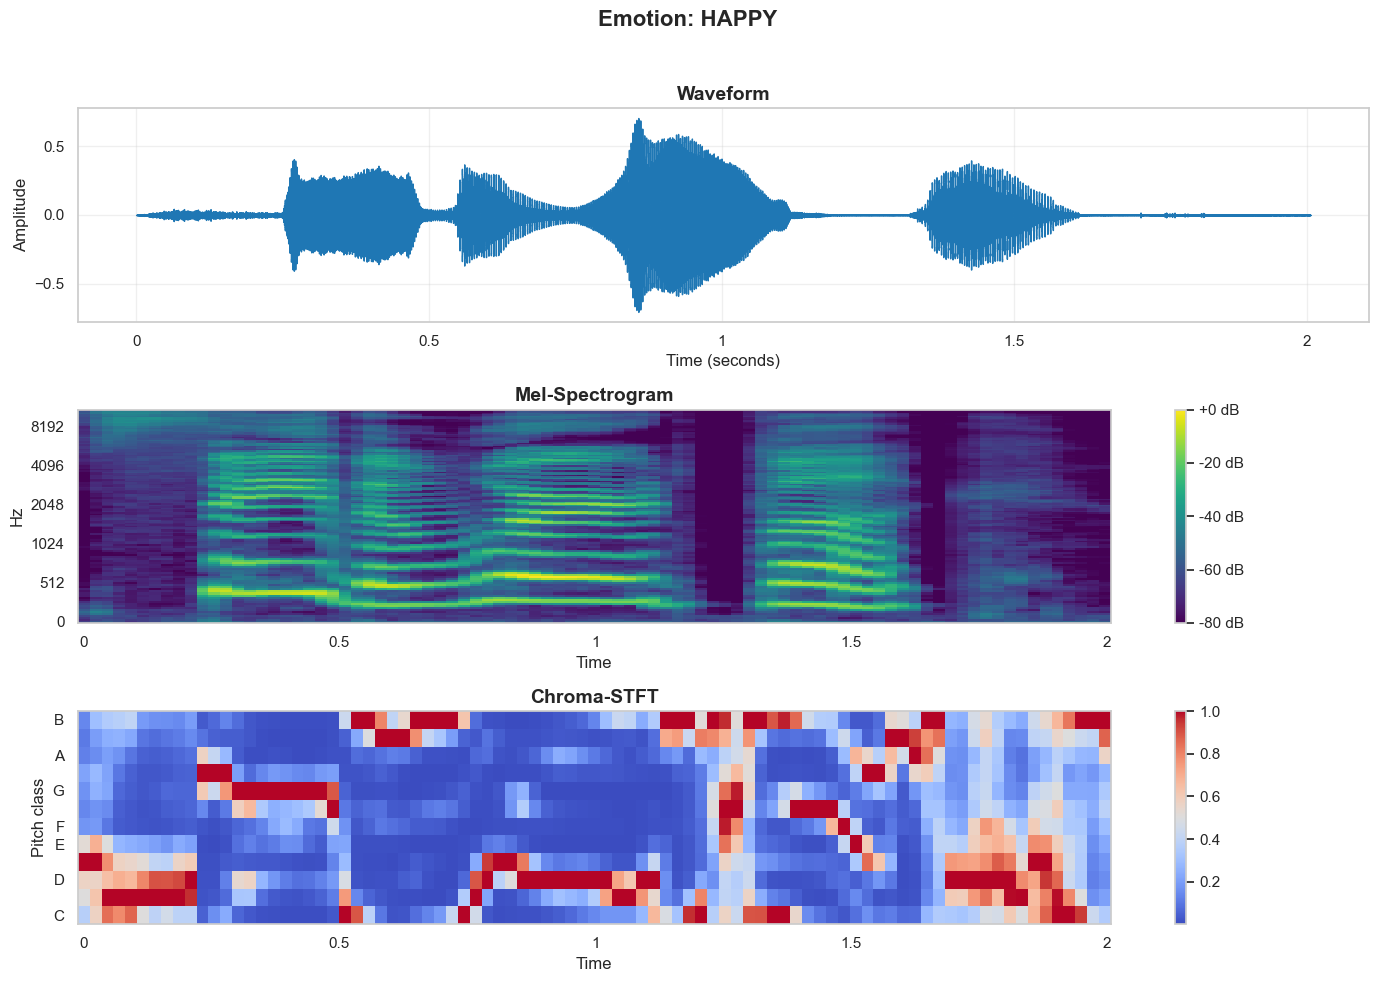

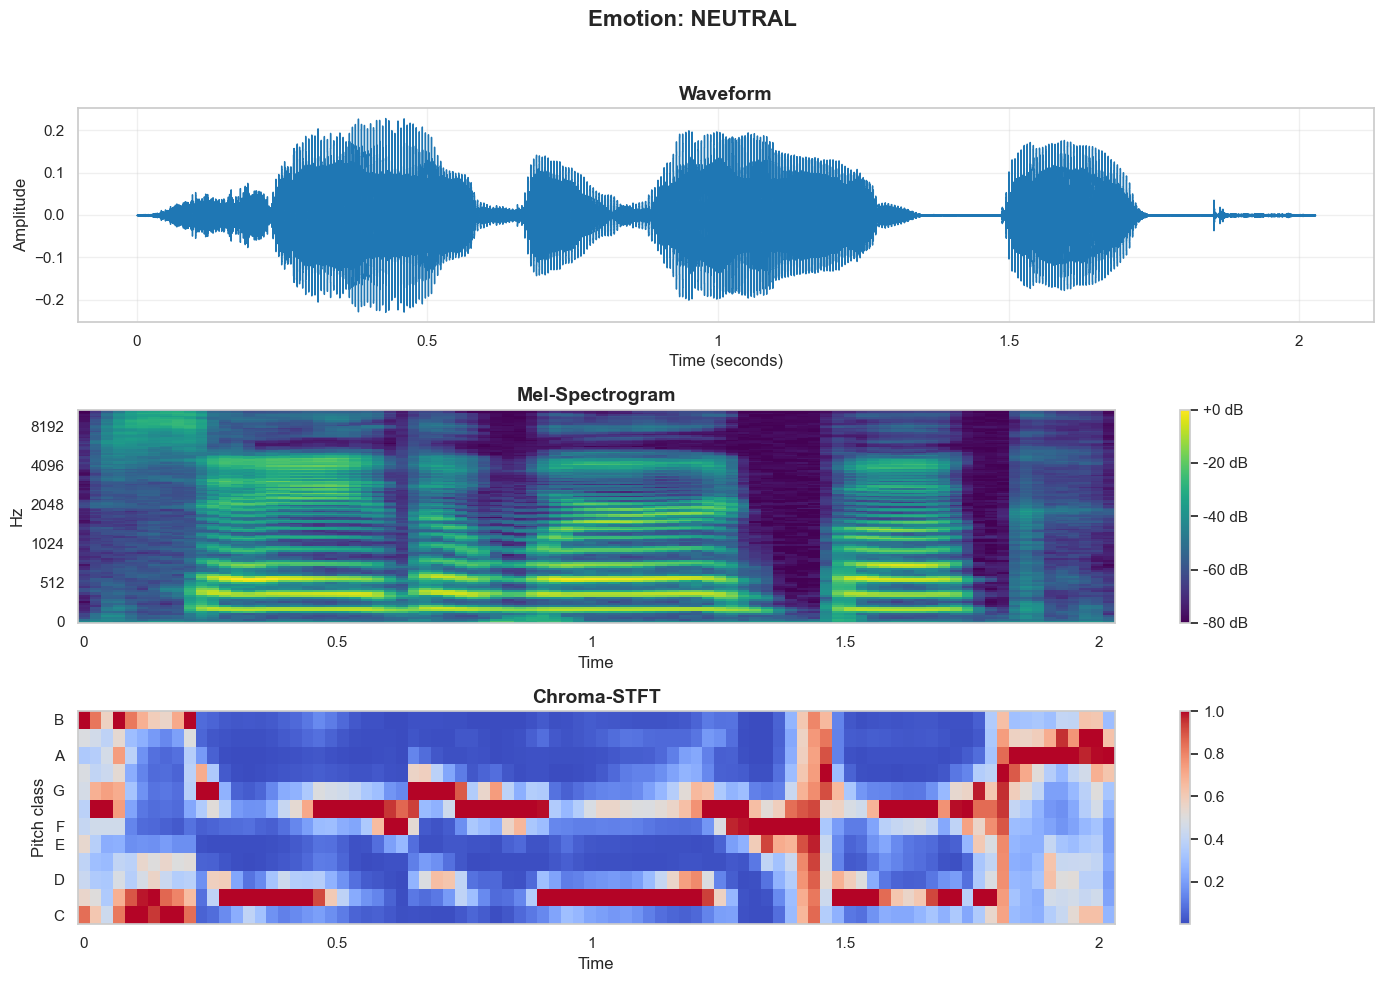

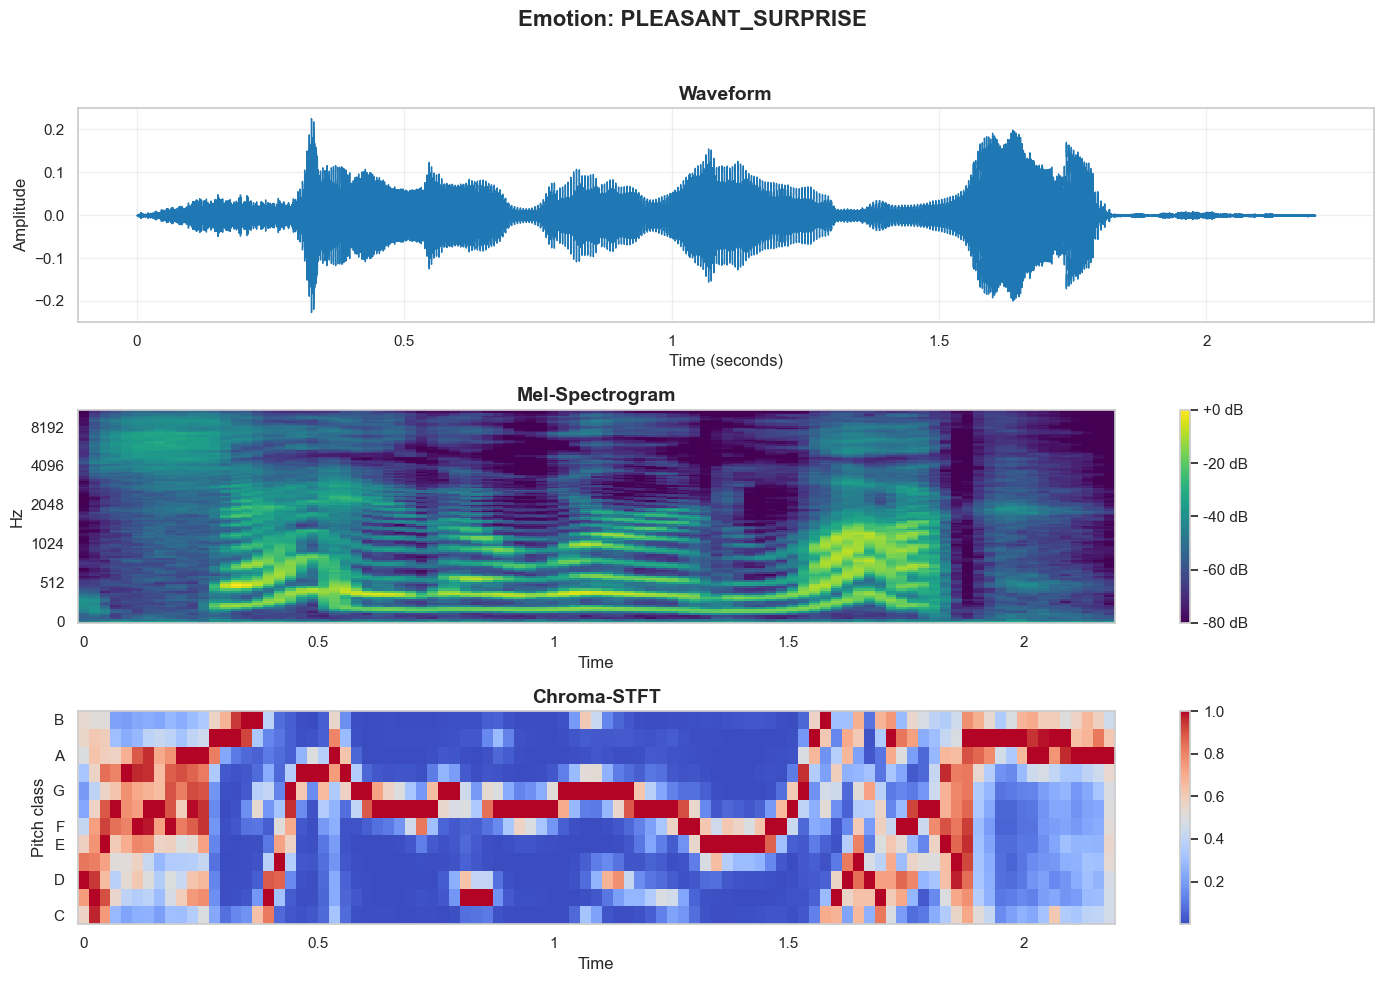

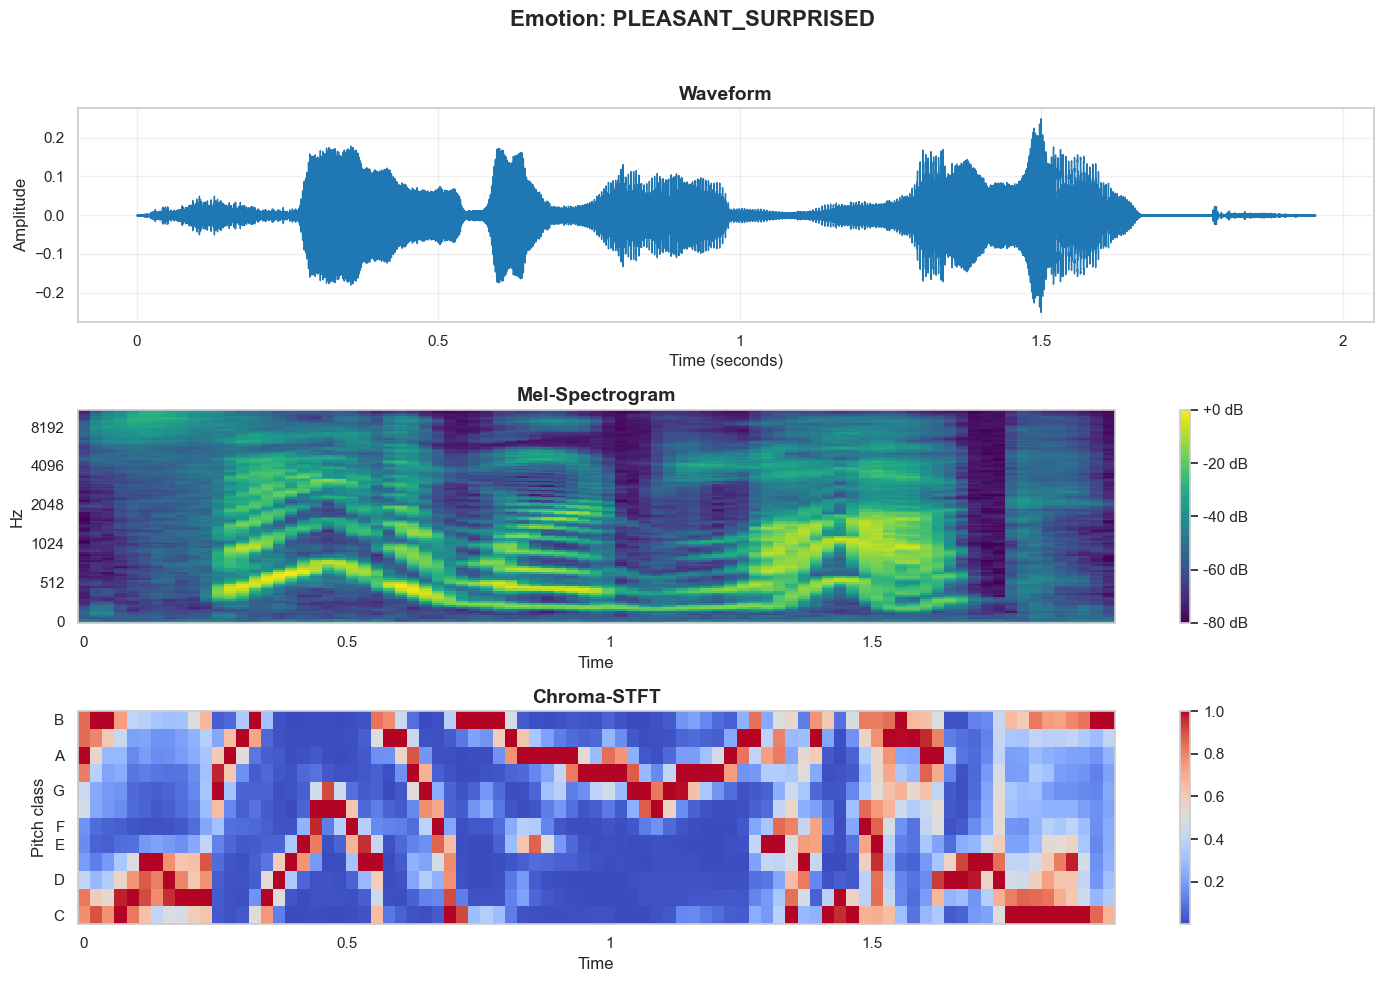

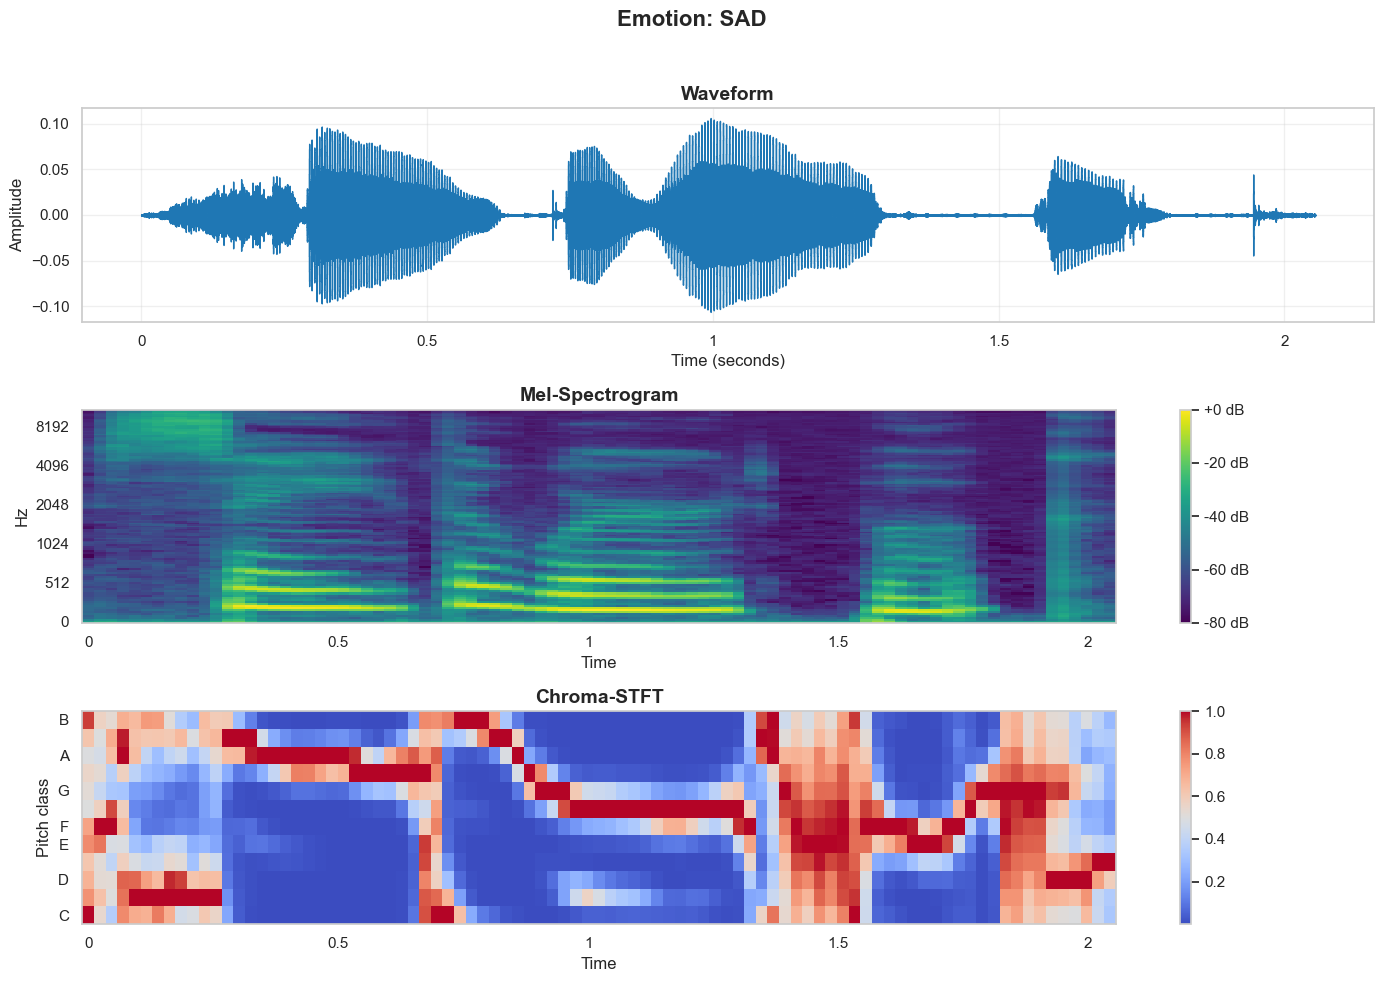

In [15]:
def compute_duration_if_missing(df):
    if 'duration_sec' not in df.columns:
        durations = []
        for p in df['paths']:
            try:
                y, sr = librosa.load(p, sr=None)
                durations.append(librosa.get_duration(y=y, sr=sr))
            except:
                durations.append(np.nan)
        df['duration_sec'] = durations
    return df

def get_mean_pitch_simple(path, sr=22050, fmin=50, fmax=500):
    try:
        y, sr = librosa.load(path, sr=sr)
        f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr)
        f0 = f0[~np.isnan(f0)]
        return float(np.mean(f0)) if f0.size>0 else np.nan
    except:
        return np.nan

def compute_mean_pitch_if_missing(df):
    if 'mean_pitch' not in df.columns:
        df['mean_pitch'] = df['paths'].apply(lambda p: get_mean_pitch_simple(p))
    return df

def plot_and_play(path, emotion, sr=22050):
    try:
        y, sr = librosa.load(path, sr=sr)
    except Exception as e:
        print("Error loading:", path, e)
        return

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"Emotion: {emotion.upper()}", fontsize=16, fontweight='bold')

    plt.subplot(3,1,1)
    librosa.display.waveshow(y, sr=sr, color="#1f77b4")
    plt.title("Waveform", fontsize=14, fontweight='bold')
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(3,1,2)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', cmap="viridis")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel-Spectrogram", fontsize=14, fontweight='bold')

    plt.subplot(3,1,3)
    C = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(C, sr=sr, x_axis='time', y_axis='chroma', cmap="coolwarm")
    plt.colorbar()
    plt.title("Chroma-STFT", fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    display(Audio(y, rate=sr))

tess_data = compute_duration_if_missing(tess_data)
tess_data = compute_mean_pitch_if_missing(tess_data)

classes = sorted(tess_data['emotions'].unique())

summary_rows = []
for emo in classes:
    subset = tess_data[tess_data['emotions'] == emo]
    summary_rows.append({
        'Emotion': emo,
        'Files': len(subset),
        'Mean Duration (s)': round(subset['duration_sec'].mean(), 2),
        'Mean Pitch (Hz)': round(subset['mean_pitch'].mean(), 2),
        'Min Duration': round(subset['duration_sec'].min(), 2),
        'Max Duration': round(subset['duration_sec'].max(), 2)
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plt.figure(figsize=(10,5))
plt.bar(summary_df['Emotion'], summary_df['Files'], color="#7a5195")
plt.title("TESS: Number of Files per Emotion", fontsize=16, fontweight='bold')
plt.xlabel("Emotion")
plt.ylabel("File Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

for emo in classes:
    sample_row = tess_data[tess_data['emotions']==emo].sample(n=1, random_state=42).iloc[0]
    plot_and_play(sample_row['paths'], emo)